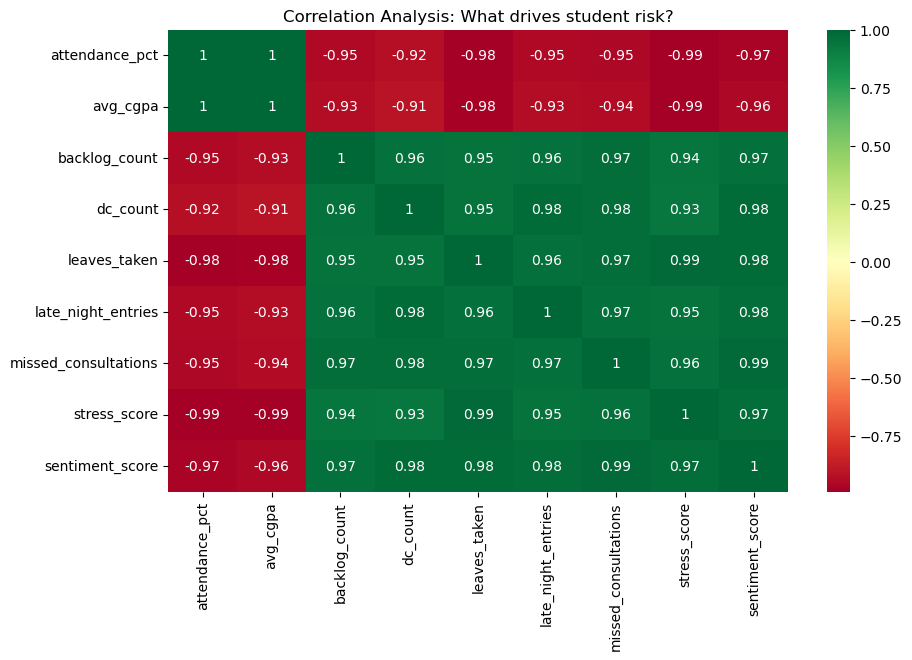

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load
df = pd.read_csv('mentor_mentee_ml_dataset.csv')

# Feature correlation: See how factors relate to each other
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(['roll_no', 'risk_level'], axis=1).corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation Analysis: What drives student risk?")
plt.show()

In [1]:
from pathlib import Path

print("Current notebook folder:")
print(Path.cwd())

print("\nFiles in this folder:")
for f in Path.cwd().iterdir():
    print(f)

Current notebook folder:
C:\Users\KIIT0001\Tutormentor

Files in this folder:
C:\Users\KIIT0001\Tutormentor\.ipynb_checkpoints
C:\Users\KIIT0001\Tutormentor\app.ipynb
C:\Users\KIIT0001\Tutormentor\app.py
C:\Users\KIIT0001\Tutormentor\developement.ipynb
C:\Users\KIIT0001\Tutormentor\encoder.pkl
C:\Users\KIIT0001\Tutormentor\final_le.joblib
C:\Users\KIIT0001\Tutormentor\final_model.joblib
C:\Users\KIIT0001\Tutormentor\final_scaler.joblib
C:\Users\KIIT0001\Tutormentor\label_encoder.joblib
C:\Users\KIIT0001\Tutormentor\mentor_dashboard.ipynb
C:\Users\KIIT0001\Tutormentor\mentor_mentee_ml_dataset.csv
C:\Users\KIIT0001\Tutormentor\mentor_model.pkl
C:\Users\KIIT0001\Tutormentor\risk_model.joblib
C:\Users\KIIT0001\Tutormentor\scaler.joblib
C:\Users\KIIT0001\Tutormentor\scaler.pkl
C:\Users\KIIT0001\Tutormentor\train_model.ipynb
C:\Users\KIIT0001\Tutormentor\tutor_action_plan.csv


In [8]:
# 1. Prepare Data
X = df.drop(['roll_no', 'risk_level'], axis=1)
y = df['risk_level']

# 2. Encode and Scale
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y_encoded)

# 4. Save artifacts so we don't have to retrain every time
joblib.dump(model, 'mentor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'encoder.pkl')

print("Model Trained and Saved Successfully!")

Model Trained and Saved Successfully!


In [9]:
def predict_and_advise(student_features):
    # Load assets
    clf = joblib.load('mentor_model.pkl')
    scl = joblib.load('scaler.pkl')
    enc = joblib.load('encoder.pkl')
    
    # Scale and Predict
    feat_scaled = scl.transform([list(student_features.values())])
    pred_idx = clf.predict(feat_scaled)
    risk = enc.inverse_transform(pred_idx)[0]
    
    # Connection Logic
    print(f"--- ASSESSING MENTEE ---")
    if risk == 'High':
        print(f"STATUS: {risk} RISK 🚨")
        print("ADVICE: Tutor, please call this student immediately. High stress and low attendance detected.")
    elif risk == 'Medium':
        print(f"STATUS: {risk} RISK ⚠️")
        print("ADVICE: Schedule a check-in meeting for next week. Monitor their next assessment.")
    else:
        print(f"STATUS: {risk} RISK ✅")
        print("ADVICE: Student is on track. Send a word of encouragement!")

# Change these values to simulate different students!
new_mentee = {
    'attendance_pct': 95,
    'avg_cgpa': 6.2,
    'backlog_count': 1,
    'dc_count': 0,
    'leaves_taken': 4,
    'late_night_entries': 2,
    'missed_consultations': 3,
    'stress_score': 1,
    'sentiment_score': 0.6
}

predict_and_advise(new_mentee)

--- ASSESSING MENTEE ---
STATUS: Medium RISK ⚠️
ADVICE: Schedule a check-in meeting for next week. Monitor their next assessment.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_16852\975341717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


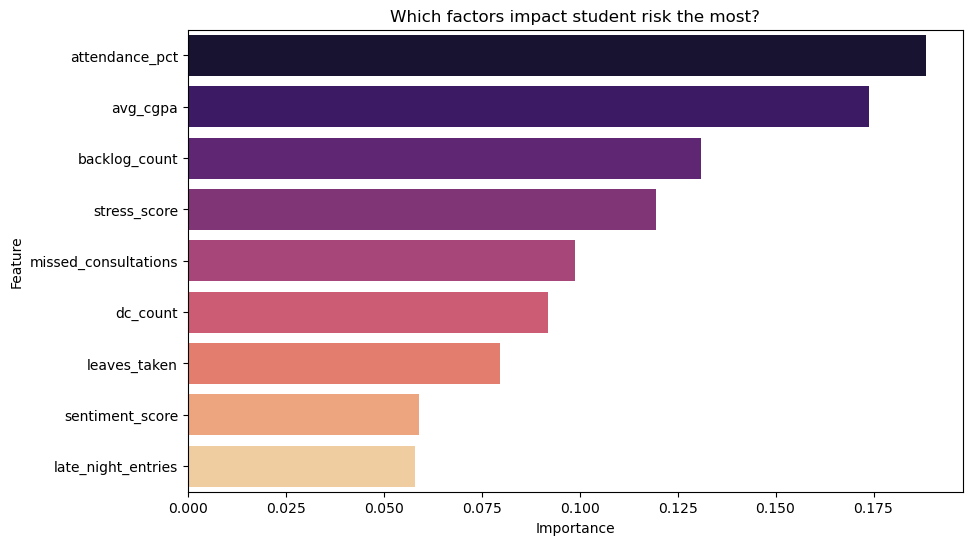

Insight: Focus on the top 3 factors when talking to mentees.


In [10]:
# Calculate Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Which factors impact student risk the most?')
plt.show()

print("Insight: Focus on the top 3 factors when talking to mentees.")

In [11]:
def generate_tutor_dashboard(data_file):
    # Load data and model
    data = pd.read_csv(data_file)
    clf = joblib.load('mentor_model.pkl')
    scl = joblib.load('scaler.pkl')
    enc = joblib.load('encoder.pkl')
    
    # Prepare features for all students
    features = data.drop(['roll_no', 'risk_level'], axis=1)
    features_scaled = scl.transform(features)
    
    # Predict for everyone at once
    predictions_idx = clf.predict(features_scaled)
    data['Predicted_Risk'] = enc.inverse_transform(predictions_idx)
    
    # Add a 'Priority' column for the tutor
    priority_map = {'High': 1, 'Medium': 2, 'Low': 3}
    data['Priority'] = data['Predicted_Risk'].map(priority_map)
    
    # Sort by Priority (High Risk first)
    dashboard = data.sort_values(by='Priority').drop('Priority', axis=1)
    
    # Styling the table for the tutor
    def highlight_risk(val):
        if val == 'High': return 'background-color: #ffcccc' # Red
        if val == 'Medium': return 'background-color: #fff3cd' # Yellow
        return ''

    print("TUTOR PRIORITY LIST (Sorted by Urgency)")
    return dashboard.style.applymap(highlight_risk, subset=['Predicted_Risk'])

# Run the dashboard
generate_tutor_dashboard('mentor_mentee_ml_dataset.csv')

TUTOR PRIORITY LIST (Sorted by Urgency)


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_16852\1179899831.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return dashboard.style.applymap(highlight_risk, subset=['Predicted_Risk'])


,roll_no,attendance_pct,avg_cgpa,backlog_count,dc_count,leaves_taken,late_night_entries,missed_consultations,stress_score,sentiment_score,risk_level,Predicted_Risk
1,102,55,5.800000,2,3,6,2,4,7,0.800000,High,High
5,106,50,5.100000,3,4,7,3,5,8,0.900000,High,High
11,112,52,5.400000,3,3,6,2,4,7,0.850000,High,High
8,109,60,6.000000,2,2,5,2,3,6,0.600000,High,High
14,115,58,5.900000,2,2,5,2,3,6,0.600000,High,High
17,118,48,5.000000,3,4,7,3,5,9,0.950000,High,High
3,104,65,6.200000,1,1,4,1,2,5,0.400000,Medium,Medium
6,107,72,7.000000,1,1,3,1,1,4,0.300000,Medium,Medium
13,114,74,7.100000,1,1,3,1,1,4,0.300000,Medium,Medium
10,111,68,6.500000,1,1,4,1,2,5,0.400000,Medium,Medium


In [6]:
# Create the final report for the tutor to take home
final_results = generate_tutor_dashboard('mentor_mentee_ml_dataset.csv').data
final_results.to_csv('tutor_action_plan.csv', index=False)

print("Project Complete! 'tutor_action_plan.csv' has been generated.")
print("You can now open this file in Excel to see your prioritized mentee list.")

TUTOR PRIORITY LIST (Sorted by Urgency)
Project Complete! 'tutor_action_plan.csv' has been generated.
You can now open this file in Excel to see your prioritized mentee list.


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_16852\1179899831.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return dashboard.style.applymap(highlight_risk, subset=['Predicted_Risk'])
